In [2]:
# ==============================
# 1. Import the libraries we need
# ==============================
# numpy: numerical arrays and random number generation
# matplotlib: plotting sample signals and training curves
# sklearn: train/test split and evaluation metrics
# tensorflow.keras: model definition and training

import os, glob, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as scipy_signal
from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import os

# Make the random results reproducible
np.random.seed(42)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
print('Imports OK.')

I0000 00:00:1776926073.595204    9524 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776926073.599102    9524 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776926073.910843    9524 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776926075.940072    9524 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENAB

Imports OK.


In [3]:
DATA_ROOT = '../ML/DynamicTrainingData'   # <-- change this to point to your data folder

# Labels to INCLUDE. Set to None to use ALL subfolders automatically.
# Example: INCLUDE_LABELS = ['TwoHand_L_Fist_R_Fist', 'TwoHand_L_Flat_R_Flat']
INCLUDE_LABELS = None

# =============================================================================
# 1B. COLUMN SELECTION
# =============================================================================
# Choose which sensor modalities to include.
# Each flag independently includes/excludes that group of columns.

USE_YAW_PITCH_ROLL   = True    # IMU Euler angles (yaw, pitch, roll / heading)
USE_QUATERNIONS      = False   # Raw quaternion components (quat_w/x/y/z)
                               # Note: for TwoHand_L_Flat_R_Flat, quaternions are
                               #       the primary data — pitch/roll/yaw are derived.
                               #       Set True if using that label.
USE_ACCELEROMETER    = True    # Linear accelerometer (ax, ay, az)
USE_FLEX_SENSORS     = True    # Flex sensor readings (mcp_flex, pip_flex)

# Choose which body segments to include.
# Available: 'palm_prox', 'thumb', 'index', 'middle', 'ring', 'pinky', 'wrist'
# 'palm_mid'  = excluded — IMU columns exist in CSV but contain no sensor data
# 'palm_prox' = IMU on back of palm (proximal, near wrist)
# 'wrist'     = IMU at end of forearm closest to wrist
# Note: flex sensors exist for fingers only (thumb, index, middle, ring, pinky) — NOT palm
INCLUDE_SEGMENTS = [
    # 'palm_mid',  # excluded: IMU columns exist but contain no data
    'palm_prox',
    'thumb',
    'index',
    'middle',
    'ring',
    'pinky',
    'wrist',
]

# Choose which hands to include
INCLUDE_HANDS = ['left', 'right']  # options: 'left', 'right', or both

In [4]:
# =============================================================================
# 1C. PREPROCESSING
# =============================================================================

# --- Resampling ---
# Resample each trial to a fixed number of time steps (handles variable-length files).
# Set to None to skip resampling (all files must then have the same row count).
RESAMPLE_TO_N_STEPS = 100       # target number of rows per trial

# --- Low-pass Butterworth filter ---
APPLY_BUTTERWORTH    = True     # Apply low-pass filter to smooth IMU noise
BUTTERWORTH_CUTOFF   = 5.0      # Cutoff frequency in Hz
BUTTERWORTH_ORDER    = 4        # Filter order
SAMPLING_RATE_HZ     = 22.0     # Approximate sampling rate of the glove

# --- Normalisation ---
# 'standard'  → zero mean, unit variance (StandardScaler) — good for SVM, LDA
# 'minmax'    → scale to [0, 1]  (MinMaxScaler) — good for KNN, neural nets
# None        → no normalisation
NORMALISATION = 'standard'

# --- Feature extraction mode ---
# 'flatten'    → use the raw resampled time series as a flat feature vector
#                (n_steps × n_channels features per sample)
# 'stats'      → extract statistical features per channel
#                (mean, std, min, max, range, RMS, skew, kurtosis)
# 'fft'        → FFT magnitude spectrum per channel
# 'stats+fft'  → combine statistical + FFT features
FEATURE_MODE = 'stats'    # Recommended starting point

# =============================================================================
# 1D. TRAIN / TEST SPLIT
# =============================================================================
TEST_SIZE        = 0.2    # Fraction of data held out for testing
RANDOM_STATE     = 42
CV_FOLDS         = 2      # Number of cross-validation folds


In [5]:

# All 295 columns, grouped by type for easy selection
META_COLS = [
    'run_index', 'request_id', 'request_ts',
    'right_recv_time_ms', 'right_glove_time_ms', 'right_time',
    'left_recv_time_ms',  'left_glove_time_ms',  'left_time',
    'left_hand', 'right_hand'
]

SEGMENTS_WITH_FLEX = ['thumb', 'index', 'middle', 'ring', 'pinky']  # palm has no flex sensors
IMU_LOCATIONS = ['mid', 'prox']  # distal phalanx / proximal phalanx

def build_sensor_columns(hands, segments, use_ypr, use_quat, use_accel, use_flex):
    """Return list of sensor column names matching the user config."""
    cols = []
    for hand in hands:
        for seg in segments:
            # Determine IMU sub-locations for this segment
            # palm has mid + prox; all finger segments have mid + prox; wrist has no sub-location
            if seg == 'wrist':
                prefix = f'{hand}_wrist'
                if use_ypr:
                    cols += [f'{prefix}_heading', f'{prefix}_pitch', f'{prefix}_roll']
                if use_quat:
                    cols += [f'{prefix}_quat_w', f'{prefix}_quat_x',
                             f'{prefix}_quat_y', f'{prefix}_quat_z']
                if use_accel:
                    cols += [f'{prefix}_ax', f'{prefix}_ay', f'{prefix}_az']
                # wrist has no flex sensor
            else:
                # segment has mid + prox IMU positions
                # For 'thumb','index' etc, map to e.g. 'left_thumb_mid_yaw'
                for loc in ['mid', 'prox']:
                    prefix = f'{hand}_{seg}_{loc}'
                    if use_ypr:
                        cols += [f'{prefix}_yaw', f'{prefix}_pitch', f'{prefix}_roll']
                    if use_quat:
                        cols += [f'{prefix}_quat_w', f'{prefix}_quat_x',
                                 f'{prefix}_quat_y', f'{prefix}_quat_z']
                    if use_accel:
                        cols += [f'{prefix}_ax', f'{prefix}_ay', f'{prefix}_az']
                # Flex sensors (one per finger joint combination, not per loc)
                if use_flex and seg in ['thumb', 'index', 'middle', 'ring', 'pinky']:  # palm has no flex
                    cols += [f'{hand}_{seg}_mcp_flex', f'{hand}_{seg}_pip_flex']
    return cols

# Map user-friendly segment names to CSV naming convention
seg_map = {
    'palm_mid':  'palm',   # excluded by default — no sensor data on palm_mid
    'palm_prox': 'palm',   # deduplicated below
    'thumb':     'thumb',
    'index':     'index',
    'middle':    'middle',
    'ring':      'ring',
    'pinky':     'pinky',
    'wrist':     'wrist',
}

# Resolve segments, de-duplicating palm if both palm_mid and palm_prox selected
resolved_segs = list(dict.fromkeys([seg_map[s] for s in INCLUDE_SEGMENTS]))

SENSOR_COLS = build_sensor_columns(
    hands    = INCLUDE_HANDS,
    segments = resolved_segs,
    use_ypr  = USE_YAW_PITCH_ROLL,
    use_quat = USE_QUATERNIONS,
    use_accel= USE_ACCELEROMETER,
    use_flex = USE_FLEX_SENSORS
)

print(f'Selected {len(SENSOR_COLS)} sensor columns.')
print('First 10:', SENSOR_COLS[:10])
print('Last 10:', SENSOR_COLS[-10:])

Selected 176 sensor columns.
First 10: ['left_palm_mid_yaw', 'left_palm_mid_pitch', 'left_palm_mid_roll', 'left_palm_mid_ax', 'left_palm_mid_ay', 'left_palm_mid_az', 'left_palm_prox_yaw', 'left_palm_prox_pitch', 'left_palm_prox_roll', 'left_palm_prox_ax']
Last 10: ['right_pinky_prox_ay', 'right_pinky_prox_az', 'right_pinky_mcp_flex', 'right_pinky_pip_flex', 'right_wrist_heading', 'right_wrist_pitch', 'right_wrist_roll', 'right_wrist_ax', 'right_wrist_ay', 'right_wrist_az']


In [6]:
# ── Load all CSV files ─────────────────────────────────────────────────────────

def load_dataset(data_root, include_labels, sensor_cols):
    """Load all CSVs from label subfolders. Returns list of (df_trial, label)."""
    data_root = os.path.expanduser(data_root)
    if not os.path.isdir(data_root):
        raise FileNotFoundError(
            f"DATA_ROOT not found: '{data_root}'\n"
            "Please update DATA_ROOT in the Configuration cell to point to your "
            "ThesisA.data folder."
        )

    label_dirs = sorted([
        d for d in os.listdir(data_root)
        if os.path.isdir(os.path.join(data_root, d))
        and d not in ('PDF', 'sdb', 'idk')  # skip non-gesture folders
    ])

    if include_labels is not None:
        label_dirs = [d for d in label_dirs if d in include_labels]

    if not label_dirs:
        raise ValueError('No label folders found. Check DATA_ROOT and INCLUDE_LABELS.')

    print(f'Found {len(label_dirs)} gesture classes:')
    trials, labels = [], []

    for label in label_dirs:
        folder = os.path.join(data_root, label)
        csv_files = sorted(glob.glob(os.path.join(folder, '*.csv')))
        print(f'  [{label}]  →  {len(csv_files)} files')
        for fpath in csv_files:
            try:
                df = pd.read_csv(fpath)
                # Keep only sensor columns that exist in this file
                available = [c for c in sensor_cols if c in df.columns]
                if not available:
                    print(f'    WARNING: no matching sensor columns in {os.path.basename(fpath)}')
                    continue
                trials.append(df[available].values.astype(np.float32))
                labels.append(label)
            except Exception as e:
                print(f'    ERROR loading {os.path.basename(fpath)}: {e}')

    print(f'\nTotal trials loaded: {len(trials)}')
    return trials, labels, label_dirs

trials_raw, labels_raw, class_names = load_dataset(
    DATA_ROOT, INCLUDE_LABELS, SENSOR_COLS
)

# Class distribution
from collections import Counter
print('\nClass distribution:')
for cls, cnt in sorted(Counter(labels_raw).items()):
    print(f'  {cls}: {cnt} trials')

Found 5 gesture classes:
  [TwoHandDynamic_L_Best_R_Best_filtered_butterworth_lp]  →  10 files
  [TwoHandDynamic_L_JustKidding_R_JustKidding_filtered_butterworth_lp]  →  11 files
  [TwoHandDynamic_L_Like_R_Like_filtered_butterworth_lp]  →  10 files
  [TwoHandDynamic_L_No_R_No_filtered_butterworth_lp]  →  10 files
  [TwoHandDynamic_L_Nobody_R_Nobody_filtered_butterworth_lp]  →  10 files

Total trials loaded: 51

Class distribution:
  TwoHandDynamic_L_Best_R_Best_filtered_butterworth_lp: 10 trials
  TwoHandDynamic_L_JustKidding_R_JustKidding_filtered_butterworth_lp: 11 trials
  TwoHandDynamic_L_Like_R_Like_filtered_butterworth_lp: 10 trials
  TwoHandDynamic_L_No_R_No_filtered_butterworth_lp: 10 trials
  TwoHandDynamic_L_Nobody_R_Nobody_filtered_butterworth_lp: 10 trials


In [19]:
# ── Step 1: Resample to fixed length ──────────────────────────────────────────

def resample_trial(trial, n_steps):
    """Resample a (T, C) array to (n_steps, C) using linear interpolation."""
    T, C = trial.shape
    if T == n_steps:
        return trial
    old_idx = np.linspace(0, 1, T)
    new_idx = np.linspace(0, 1, n_steps)
    resampled = np.zeros((n_steps, C), dtype=np.float32)
    for c in range(C):
        resampled[:, c] = np.interp(new_idx, old_idx, trial[:, c])
    return resampled

if RESAMPLE_TO_N_STEPS is not None:
    trials_resampled = [resample_trial(t, RESAMPLE_TO_N_STEPS) for t in trials_raw]
    print(f'Resampled all trials to {RESAMPLE_TO_N_STEPS} time steps.')
else:
    trials_resampled = trials_raw
    lengths = [t.shape[0] for t in trials_resampled]
    print(f'No resampling. Trial lengths: min={min(lengths)}, max={max(lengths)}, mean={np.mean(lengths):.1f}')
    if min(lengths) != max(lengths):
        print('  WARNING: Variable-length trials detected. Enable RESAMPLE_TO_N_STEPS '
              'or use a feature extraction mode that handles variable length.')

print(f'Trial shape: {trials_resampled[0].shape}  (time_steps × channels)')
sequence_length, n_channels = trials_resampled[0].shape
print(f'Sequence length: {sequence_length}, Number of channels: {n_channels}')

Resampled all trials to 100 time steps.
Trial shape: (100, 176)  (time_steps × channels)
Sequence length: 100, Number of channels: 176


In [8]:
# ── Step 2: Butterworth low-pass filter ───────────────────────────────────────

def apply_butterworth(trials, cutoff, order, fs):
    """Apply a zero-phase Butterworth low-pass filter to each channel of each trial."""
    nyq = fs / 2.0
    norm_cutoff = cutoff / nyq
    if norm_cutoff >= 1.0:
        print(f'  WARNING: cutoff {cutoff} Hz >= Nyquist {nyq} Hz — skipping filter.')
        return trials
    b, a = scipy_signal.butter(order, norm_cutoff, btype='low', analog=False)
    filtered = []
    for t in trials:
        t_filt = scipy_signal.filtfilt(b, a, t, axis=0).astype(np.float32)
        filtered.append(t_filt)
    return filtered

if APPLY_BUTTERWORTH:
    trials_filtered = apply_butterworth(
        trials_resampled, BUTTERWORTH_CUTOFF, BUTTERWORTH_ORDER, SAMPLING_RATE_HZ
    )
    print(f'Applied Butterworth low-pass filter: {BUTTERWORTH_CUTOFF} Hz cutoff, '
          f'order {BUTTERWORTH_ORDER}, Nyquist = {SAMPLING_RATE_HZ/2} Hz')
else:
    trials_filtered = trials_resampled
    print('Butterworth filter skipped.')

Applied Butterworth low-pass filter: 5.0 Hz cutoff, order 4, Nyquist = 11.0 Hz


In [9]:
print(f'Filtered trial shape: {trials_filtered[0].shape}  (time_steps × channels)')

Filtered trial shape: (100, 176)  (time_steps × channels)


In [10]:
print(len(trials_filtered), 'trials ready for feature extraction.')
print(labels_raw)

51 trials ready for feature extraction.
['TwoHandDynamic_L_Best_R_Best_filtered_butterworth_lp', 'TwoHandDynamic_L_Best_R_Best_filtered_butterworth_lp', 'TwoHandDynamic_L_Best_R_Best_filtered_butterworth_lp', 'TwoHandDynamic_L_Best_R_Best_filtered_butterworth_lp', 'TwoHandDynamic_L_Best_R_Best_filtered_butterworth_lp', 'TwoHandDynamic_L_Best_R_Best_filtered_butterworth_lp', 'TwoHandDynamic_L_Best_R_Best_filtered_butterworth_lp', 'TwoHandDynamic_L_Best_R_Best_filtered_butterworth_lp', 'TwoHandDynamic_L_Best_R_Best_filtered_butterworth_lp', 'TwoHandDynamic_L_Best_R_Best_filtered_butterworth_lp', 'TwoHandDynamic_L_JustKidding_R_JustKidding_filtered_butterworth_lp', 'TwoHandDynamic_L_JustKidding_R_JustKidding_filtered_butterworth_lp', 'TwoHandDynamic_L_JustKidding_R_JustKidding_filtered_butterworth_lp', 'TwoHandDynamic_L_JustKidding_R_JustKidding_filtered_butterworth_lp', 'TwoHandDynamic_L_JustKidding_R_JustKidding_filtered_butterworth_lp', 'TwoHandDynamic_L_JustKidding_R_JustKidding_filte

In [11]:
# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels_raw)
print(f'Labels encoded: {dict(zip(le.classes_, range(len(le.classes_))))}')

n_classes = num_unique = len(set(y))
print(f'Number of classes: {n_classes}')

Labels encoded: {np.str_('TwoHandDynamic_L_Best_R_Best_filtered_butterworth_lp'): 0, np.str_('TwoHandDynamic_L_JustKidding_R_JustKidding_filtered_butterworth_lp'): 1, np.str_('TwoHandDynamic_L_Like_R_Like_filtered_butterworth_lp'): 2, np.str_('TwoHandDynamic_L_No_R_No_filtered_butterworth_lp'): 3, np.str_('TwoHandDynamic_L_Nobody_R_Nobody_filtered_butterworth_lp'): 4}
Number of classes: 5


In [12]:
print(y)

[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3
 3 3 3 3 4 4 4 4 4 4 4 4 4 4]


In [13]:
bad = np.isnan(trials_filtered) | np.isinf(trials_filtered)
if bad.any():
    print(f'WARNING: {bad.sum()} NaN/Inf values found — replacing with 0.')
X = np.nan_to_num(trials_filtered, nan=0.0, posinf=0.0, neginf=0.0)

print(f'Feature matrix shape: {X.shape}  ({X.shape[0]} trials × {X.shape[1]} features)')


Feature matrix shape: (51, 100, 176)  (51 trials × 100 features)


In [14]:
print(f"Test Size: {TEST_SIZE*100:.1f}%  →  {int(len(X)*TEST_SIZE)} samples in test set")
print(f"CV Folds: {CV_FOLDS}  →  {int(len(X)*(1-TEST_SIZE)/CV_FOLDS)} samples per fold")
print(f"Total samples: {len(X)}  →  Train+Val: {len(X)*(1-TEST_SIZE):.0f}, Test: {len(X)*TEST_SIZE:.0f}")
print(f"Stratify by label: {len(np.unique(y))} classes, distribution: {Counter(y)}")

Test Size: 20.0%  →  10 samples in test set
CV Folds: 2  →  20 samples per fold
Total samples: 51  →  Train+Val: 41, Test: 10
Stratify by label: 5 classes, distribution: Counter({np.int64(1): 11, np.int64(0): 10, np.int64(2): 10, np.int64(3): 10, np.int64(4): 10})


In [15]:
# ── Step 4: Normalise + split ─────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

if NORMALISATION == 'standard':
    scaler = StandardScaler()
elif NORMALISATION == 'minmax':
    scaler = MinMaxScaler()
else:
    scaler = None

if scaler is not None:
    # X_train = scaler.fit_transform(X_train)
    # X_test  = scaler.transform(X_test)

    N, C, T = X_train.shape

    # Flatten (N, C, T) -> (N, C*T)
    X_train_flat = X_train.reshape(N, C * T)
    X_test_flat  = X_test.reshape(X_test.shape[0], C * T)

    # Fit on train, transform both
    X_train_scaled_flat = scaler.fit_transform(X_train_flat)
    X_test_scaled_flat  = scaler.transform(X_test_flat)

    # Reshape back to (N, C, T)
    X_train = X_train_scaled_flat.reshape(N, C, T)
    X_test  = X_test_scaled_flat.reshape(X_test.shape[0], C, T)

    print(f'Applied {NORMALISATION} normalisation.')
else:
    print('No normalisation applied.')

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

Applied standard normalisation.
Train: 40 samples | Test: 11 samples


fit_transform both learns parameters from the data and applies the transformation, while transform only applies parameters that were learned earlier.

What each one does
fit(X): compute parameters from X (for StandardScaler, this is the mean and standard deviation of each feature) and store them inside scaler.

transform(X): use the already stored parameters to transform new data X (e.g., subtract the stored mean and divide by the stored std).

fit_transform(X): convenience method that does fit(X) followed by transform(X) in one call.

# Training and Evaluation

In [24]:
# =========================
# 5. Build the 1D CNN model
# =========================
# The main idea behind Conv1D:
# - Convolution layers scan along the time axis
# - Filters learn local temporal patterns
# - Pooling reduces sequence size and keeps the strongest features
# - Dense layers perform the final classification

model = Sequential([
    # First convolution layer:
    # 32 filters, kernel size 3 means each filter looks at 3 time steps at once
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(sequence_length, n_channels)),

    # Pooling reduces the time dimension by taking the maximum in each window
    MaxPooling1D(pool_size=2),

    # A second convolution layer can learn more complex patterns
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    # Flatten converts the 3D feature maps into a 1D vector
    Flatten(),

    # Dense layer learns combinations of the extracted features
    Dense(64, activation='relu'),

    # Dropout helps reduce overfitting by randomly dropping neurons during training
    Dropout(0.3),

    # Final layer uses softmax for multi-class classification
    Dense(n_classes, activation='softmax')
])

# Compile the model:
# - optimizer='adam' updates the weights efficiently
# - loss='categorical_crossentropy' is suitable for one-hot labels
# - accuracy lets us track classification performance during training
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 98, 32)         │        16,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 49, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 47, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1472)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        94,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,733 (459.89 KB)

 Trainable params: 117,733 (459.89 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# ====================
# 6. Train the model
# ====================
# We train for a small number of epochs so the notebook runs quickly.
# validation_split=0.2 means 20% of the training data is used for
# validation during training.

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1875 - loss: 1.8432 - val_accuracy: 0.5000 - val_loss: 1.5764
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.6562 - loss: 1.1252 - val_accuracy: 0.5000 - val_loss: 1.2964
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.7500 - loss: 0.8495 - val_accuracy: 1.0000 - val_loss: 0.9608
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.9688 - loss: 0.5520 - val_accuracy: 1.0000 - val_loss: 0.6557
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.9688 - loss: 0.3809 - val_accuracy: 1.0000 - val_loss: 0.4137
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9688 - loss: 0.2858 - val_accuracy: 1.0000 - val_loss: 0.2481
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 1.0000 - loss: 0.1322 - val_accuracy: 1.0000 - val_loss: 0.1583
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 1.0000 - loss: 0.0468 - val_accuracy: 1.0000 - val_loss: 0.1132
Epoch 

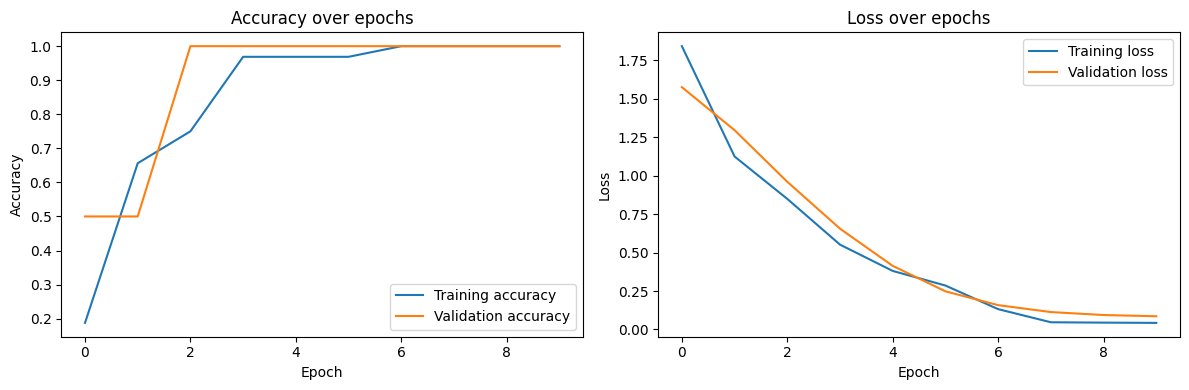

In [26]:
# ====================================
# 7. Plot training and validation loss
# ====================================
# These curves help you diagnose training behavior:
# - If both improve, training is working
# - If training improves but validation gets worse, you may be overfitting

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
# ========================
# 8. Evaluate the model
# ========================
# First, evaluate overall loss and accuracy on the held-out test set.

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

Test loss: 0.0105
Test accuracy: 1.0000


In [30]:
# ============================================
# 9. Generate predictions and detailed metrics
# ============================================
# We convert predicted probabilities into class labels using argmax.

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

print('Confusion Matrix:')
print(confusion_matrix(y_true, y_pred))

print('\nClassification Report:')
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Confusion Matrix:
[[2 0 0 0 0]
 [0 3 0 0 0]
 [0 0 2 0 0]
 [0 0 0 2 0]
 [0 0 0 0 2]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



## Manual Testing

In [ ]:
def label_from_filename(fname):
    """
    Extract the gesture label from a filename like:
      glove_data_L_Fist_R_Fist_5s_94_2026-04-19_21-42-01_bw_lp_5.0hz.csv
    Returns the matching class label string, or None if not recognised.
    """
    # Match pattern:  L_<word>_R_<word>
    match = re.search(r'L_([A-Za-z]+)_R_([A-Za-z]+)', fname, re.IGNORECASE)
    if not match:
        return None
    left_gest  = match.group(1).lower()
    right_gest = match.group(2).lower()
    return LABEL_MAP.get((left_gest, right_gest), None)

In [32]:
BATCH_TEST_FOLDER = '../ML/ManualTesting'  # <-- update


LABEL_MAP = dict(zip(le.classes_, range(len(le.classes_))))

print(f'LABEL_MAP: {LABEL_MAP['TwoHandDynamic_L_Best_R_Best_filtered_butterworth_lp']}')

LABEL_MAP: 0
